# Gastrulation Topic Model Analysis: Pseudotime and Gene Derivatives

This notebook:
1. Loads pre-trained topic models on the gastrulation erythroid dataset
2. Selects the best model using kNN cell type classification accuracy
3. Computes and compares two pseudotime orderings:
   - Diffusion pseudotime (DPT) in topic space
   - RNA velocity pseudotime from scVelo
4. **Novel:** Computes gene expression derivatives using topic model decomposition
5. Identifies driver genes with largest derivatives per cell type

## Mathematical Framework

In a topic model, gene expression can be decomposed as:
$$g = \theta \cdot \Phi^T$$

Where:
- $g$ is the reconstructed gene expression vector (1 x n_genes)
- $\theta$ is the cell-topic proportion (1 x n_topics)  
- $\Phi$ is the topic-gene loading matrix (n_genes x n_topics)

Taking the derivative with respect to pseudotime $t$:
$$\frac{dg}{dt} = \frac{d\theta}{dt} \cdot \Phi^T$$

This allows us to analytically compute gene expression changes based on topic proportion changes.

In [ ]:
import os
import gc
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mudata as md
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import torch
from scipy import stats
from scipy.stats import spearmanr, pearsonr
from scipy.cluster import hierarchy
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder

try:
    import scvelo as scv
except ImportError as err:
    raise ImportError("scvelo is required. Install with: pip install scvelo") from err

from omics_topic.models.amortizedLDA import MultimodalAmortizedLDA

warnings.filterwarnings('ignore')
scv.settings.set_figure_params('scvelo')

MODELS_DIR = Path("/data/omics_topic_models/gastrulation")
MODELS_DIR_MF = Path("/data/omics_topic_models/gastrulation_meanfield")
BASELINES_DIR = MODELS_DIR / "baselines"

## 1. Load Data

In [2]:
def load_gastrulation_data():
    """Load and preprocess gastrulation erythroid data."""
    adata = scv.datasets.gastrulation_erythroid()
    
    # Filter genes with non-zero counts
    spliced = adata.layers["spliced"]
    unspliced = adata.layers["unspliced"]
    mature_counts = np.asarray(spliced.sum(axis=0)).ravel()
    immature_counts = np.asarray(unspliced.sum(axis=0)).ravel()
    nonzero = (mature_counts > 0) | (immature_counts > 0)
    adata = adata[:, nonzero].copy()
    
    # Create MuData for topic model
    adata_mature = adata.copy()
    adata_mature.X = adata.layers["spliced"]
    adata_mature.layers.clear()
    
    adata_immature = adata.copy()
    adata_immature.X = adata.layers["unspliced"]
    adata_immature.layers.clear()
    
    mdata = md.MuData({"mature": adata_mature, "immature": adata_immature})
    
    print(f"Loaded {adata.n_obs} cells x {adata.n_vars} genes")
    print(f"Cell types: {adata.obs['celltype'].nunique()} unique")
    print(f"Stages: {adata.obs['stage'].unique().tolist()}")
    
    return mdata, adata

mdata, adata = load_gastrulation_data()
cell_types = adata.obs['celltype'].values

print("\nCell type distribution:")
print(adata.obs['celltype'].value_counts())

Loaded 9815 cells x 23622 genes
Cell types: 5 unique
Stages: ['E7.5', 'E7.75', 'E7.0', 'E8.0', 'E8.5', 'E7.25', 'E8.25']

Cell type distribution:
celltype
Erythroid1             2929
Erythroid3             2697
Blood progenitors 2    2460
Erythroid2             1106
Blood progenitors 1     623
Name: count, dtype: int64


## 2. Load Trained Topic Models and Select Best

We evaluate all trained topic models using kNN (k=5) classification on cell types
and select the model with highest balanced accuracy.

In [3]:
def parse_model_config(dirname):
    """Parse hyperparameters from directory name."""
    config = {}
    config['feature_prior_type'] = 'horseshoe' if 'horseshoe' in dirname else 'logistic_normal'
    
    if 'weight_cell' in dirname:
        config['weight_mode'] = 'cell'
    elif 'weight_universal' in dirname:
        config['weight_mode'] = 'universal'
    else:
        config['weight_mode'] = 'equal'
    
    if 'learnable_disp_global' in dirname:
        config['dispersion'] = 'learnable_global'
    elif 'learnable_disp_pergene' in dirname:
        config['dispersion'] = 'learnable_pergene'
    else:
        config['dispersion'] = 'fixed'
    
    return config

def evaluate_knn_classification(X, y, k=5, test_size=0.2, random_state=42):
    """Evaluate kNN classification accuracy."""
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_val)
    return {
        "accuracy": accuracy_score(y_val, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_val, y_pred),
    }

def evaluate_knn_multiple_runs(X, y, k=5, test_size=0.2, seeds=[42, 123, 456, 789, 1011]):
    """Evaluate kNN classification with multiple random seeds."""
    accuracies = []
    balanced_accuracies = []
    for seed in seeds:
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=test_size, random_state=seed, stratify=y
        )
        knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_val)
        accuracies.append(accuracy_score(y_val, y_pred))
        balanced_accuracies.append(balanced_accuracy_score(y_val, y_pred))
    return {
        "accuracy_mean": np.mean(accuracies),
        "accuracy_std": np.std(accuracies),
        "balanced_accuracy_mean": np.mean(balanced_accuracies),
        "balanced_accuracy_std": np.std(balanced_accuracies),
    }

In [4]:
adata

AnnData object with n_obs × n_vars = 9815 × 23622
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm'
    uns: 'celltype_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'

In [ ]:
# Setup data for model loading
mdata_setup, modality_names, feat_counts = MultimodalAmortizedLDA.setup_mudata(
    mdata,
    modality_order=["mature", "immature"],
)
adata_flat = mdata.uns["_flattened_ann_data"]

# Find all model directories (original + meanfield)
model_dirs = []
for mdir, suffix in [(MODELS_DIR, ""), (MODELS_DIR_MF, "_mf")]:
    if mdir.exists():
        for d in sorted(mdir.iterdir()):
            if d.is_dir() and d.name.startswith("prior_"):
                model_dirs.append((d, suffix))

print(f"Found {len(model_dirs)} trained topic models")

# Load and evaluate all models
results = []

for model_dir, suffix in model_dirs:
    model_path = model_dir / "model"
    if not model_path.exists():
        print(f"Skipping {model_dir.name}: no model found")
        continue
    
    display_name = model_dir.name + suffix
    print(f"Loading {display_name}...")
    
    # Check for cached latent representation
    latent_cache_path = model_dir / "latent_representation.npy"
    
    try:
        if latent_cache_path.exists():
            theta_array = np.load(latent_cache_path)
            print(f"  Loaded cached latent from {latent_cache_path}")
        else:
            model = MultimodalAmortizedLDA.load(str(model_path), adata=adata_flat)
            theta = model.get_latent_representation(batch_size=mdata.n_obs)
            theta_array = theta.values.copy()
            np.save(latent_cache_path, theta_array)
            print(f"  Computed and cached latent to {latent_cache_path}")
            del model
        
        config = parse_model_config(model_dir.name)
        config["elbo"] = "TraceMeanField" if suffix == "_mf" else "Trace"
        topic_features = np.sqrt(np.clip(theta_array, a_min=0.0, a_max=None))
        knn_metrics = evaluate_knn_classification(topic_features, cell_types, k=5)
        
        results.append({
            'model_name': display_name,
            'model_path': str(model_path),
            **config,
            'knn_accuracy': knn_metrics['accuracy'],
            'knn_balanced_accuracy': knn_metrics['balanced_accuracy'],
            'theta': theta_array,
        })
        
        print(f"  kNN Acc: {knn_metrics['accuracy']:.4f}, Balanced: {knn_metrics['balanced_accuracy']:.4f}")
        
    except Exception as e:
        print(f"  Error: {e}")
    
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nSuccessfully loaded {len(results)} models")

In [6]:
# Create results DataFrame
df_results = pd.DataFrame([{k: v for k, v in r.items() if k != 'theta'} for r in results])
df_sorted = df_results.sort_values('knn_balanced_accuracy', ascending=False)

print("Model Comparison (sorted by kNN Balanced Accuracy):")
print(df_sorted[['model_name', 'feature_prior_type', 'weight_mode', 'dispersion', 'knn_balanced_accuracy']].to_string(index=False))

# Select best model
best_result = max(results, key=lambda r: r['knn_balanced_accuracy'])
best_model_name = best_result['model_name']
theta_best = best_result['theta']

print(f"\nBest model: {best_model_name}")
print(f"  Feature prior: {best_result['feature_prior_type']}")
print(f"  Weight mode: {best_result['weight_mode']}")
print(f"  Dispersion: {best_result['dispersion']}")
print(f"  kNN Accuracy: {best_result['knn_accuracy']:.4f}")
print(f"  kNN Balanced Accuracy: {best_result['knn_balanced_accuracy']:.4f}")

Model Comparison (sorted by kNN Balanced Accuracy):
                                                   model_name feature_prior_type weight_mode        dispersion  knn_balanced_accuracy
     prior_logistic_normal_weight_equal_learnable_disp_global    logistic_normal       equal  learnable_global               0.807223
                       prior_logistic_normal_weight_universal    logistic_normal   universal             fixed               0.802877
                            prior_logistic_normal_weight_cell    logistic_normal        cell             fixed               0.796388
                           prior_logistic_normal_weight_equal    logistic_normal       equal             fixed               0.795774
    prior_logistic_normal_weight_equal_learnable_disp_pergene    logistic_normal       equal learnable_pergene               0.784484
 prior_logistic_normal_weight_universal_learnable_disp_global    logistic_normal   universal  learnable_global               0.764596
      prio

In [7]:
# Load the best model to get topic-gene loadings (Phi)
best_model = MultimodalAmortizedLDA.load(best_result['model_path'], adata=adata_flat)

# Get topic-gene distribution for mature RNA (spliced)
phi_mature = best_model.get_feature_topic_dist(modality='mature')  # (n_genes x n_topics)
phi_immature = best_model.get_feature_topic_dist(modality='immature')  # (n_genes x n_topics)

print(f"Phi matrix shape (mature): {phi_mature.shape}")
print(f"Phi matrix shape (immature): {phi_immature.shape}")
print(f"Topics: {phi_mature.columns.tolist()}")

n_topics = theta_best.shape[1]

INFO     File                                                                                                      
         /data/omics_topic_models/gastrulation/prior_logistic_normal_weight_equal_learnable_disp_global/model/model
         .pt already downloaded                                                                                    


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/1000:   0%|          | 1/1000 [00:00<03:05,  5.39it/s, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/1000:   0%|          | 1/1000 [00:00<03:14,  5.15it/s, v_num=1]
Phi matrix shape (mature): (23622, 10)
Phi matrix shape (immature): (23622, 10)
Topics: ['topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9']


## 3. Pseudotime Computation

We compute two different pseudotime orderings:
1. **Diffusion Pseudotime (DPT)** - computed in topic space using topic neighbors
2. **Velocity Pseudotime** - from scVelo's RNA velocity analysis

These represent different views of developmental ordering:
- DPT captures global structure in topic space
- Velocity pseudotime captures local RNA dynamics

In [8]:
# Add topic representation to adata
adata.obsm["X_topic"] = theta_best
adata.obs["top_topic"] = pd.DataFrame(theta_best).idxmax(axis=1).astype(str).values
adata.obsm["X_topic_sqrt"]=np.sqrt(theta_best)
# Compute topic neighbors
sc.pp.neighbors(
    adata,
    use_rep="X_topic_sqrt",
    n_neighbors=30,
    metric="euclidean",
    key_added="topic_neighbors",
)

# Topic-space UMAP
sc.tl.umap(adata, neighbors_key="topic_neighbors", min_dist=0.3, key_added='topic_umap')
#adata.obsm["X_topic_umap"] = adata.obsm["X_umap"].copy()

# Leiden clustering in topic space
sc.tl.leiden(adata, neighbors_key="topic_neighbors", key_added="topic_leiden")

print("Topic neighbors and UMAP computed.")

Topic neighbors and UMAP computed.


In [9]:
# Compute diffusion map in topic space
sc.tl.diffmap(adata, neighbors_key='topic_neighbors')

# Root candidate 1: earliest-stage medoid in diffusion space
import re

def _parse_stage_numeric(x):
    m = re.search(r"(\d+\.\d+|\d+)", str(x))
    return float(m.group(1)) if m else np.nan

if "stage" in adata.obs:
    stage_str = adata.obs["stage"].astype(str)
    stage_num = stage_str.map(_parse_stage_numeric)
    if stage_num.notna().any():
        earliest_val = stage_num.min()
        early_mask = stage_num == earliest_val
        early_label = ", ".join(stage_str[early_mask].unique().tolist())
    else:
        early_mask = pd.Series(False, index=adata.obs_names)
        early_label = "unknown"
else:
    early_mask = pd.Series(False, index=adata.obs_names)
    early_label = "unknown"

# Fallback to known early cell types if stage is unavailable
if early_mask.sum() == 0 and "celltype" in adata.obs:
    fallback_celltypes = ["Blood progenitors 1"]
    early_mask = adata.obs["celltype"].isin(fallback_celltypes)
    early_label = ", ".join(fallback_celltypes)

X = adata.obsm["X_diffmap"][:, :5]
if early_mask.sum() > 0:
    early_idx = np.where(early_mask.values)[0]
    from sklearn.metrics import pairwise_distances
    D = pairwise_distances(X[early_idx])
    root_stage = int(early_idx[np.argmin(D.mean(axis=1))])
    print(f"Stage-root (medoid) from {early_label}: {root_stage}")
else:
    root_stage = int(np.argmin(X[:, 0]))
    print("Stage-root fallback to min DC1:", root_stage)

adata.uns["iroot"] = root_stage
sc.tl.dpt(adata, neighbors_key='topic_neighbors', n_branchings=0)
adata.obs["dpt_pseudotime_root_stage"] = adata.obs["dpt_pseudotime"].copy()
print(f"DPT (stage-root) range: [{adata.obs['dpt_pseudotime_root_stage'].min():.3f}, {adata.obs['dpt_pseudotime_root_stage'].max():.3f}]")


Stage-root (medoid) from E7.0: 1842
DPT (stage-root) range: [0.000, 1.000]


In [10]:
# Run scVelo velocity analysis
if "velocity" not in adata.layers:
    print("Running scVelo velocity analysis...")
    scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
    scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
    scv.tl.velocity(adata)
    scv.tl.velocity_graph(adata)

# Compute velocity pseudotime
scv.tl.velocity_pseudotime(adata)
print(f"Velocity pseudotime range: [{adata.obs['velocity_pseudotime'].min():.3f}, {adata.obs['velocity_pseudotime'].max():.3f}]")

# Root candidate 2: velocity-inferred root (then DPT on the same graph)
root_vel = None
try:
    scv.tl.terminal_states(adata)
    if "root_cells" in adata.obs:
        root_vel = int(np.argmax(adata.obs["root_cells"].values))
        adata.uns["iroot"] = root_vel
        sc.tl.dpt(adata, neighbors_key='topic_neighbors', n_branchings=0)
        adata.obs["dpt_pseudotime_root_velocity"] = adata.obs["dpt_pseudotime"].copy()
        print(f"Velocity-root (max root_cells): {root_vel}")
        print(f"DPT (velocity-root) range: [{adata.obs['dpt_pseudotime_root_velocity'].min():.3f}, {adata.obs['dpt_pseudotime_root_velocity'].max():.3f}]")
    else:
        print("No 'root_cells' found in adata.obs; skipping velocity-based root DPT")
except Exception as e:
    print(f"Velocity root inference failed: {e}")



Running scVelo velocity analysis...
Filtered out 17277 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
computing neighbors


/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/tmp/ipykernel_1246259/1105207092.py:5: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


    finished (0:00:02) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities


/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:01) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/112 cores)
or disable the progress bar using `show_progress_bar=False`.


/scratch/fcaretti/omics_topic_uv/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=1246259) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:00:10) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 6 regions of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
Velocity pseudotime range: [0.000, 1.000]
computing terminal states
    identified 6 regions of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
Velocity-root (max root_cells): 48
DPT (velocity-root) range: [0.000, 1.000]


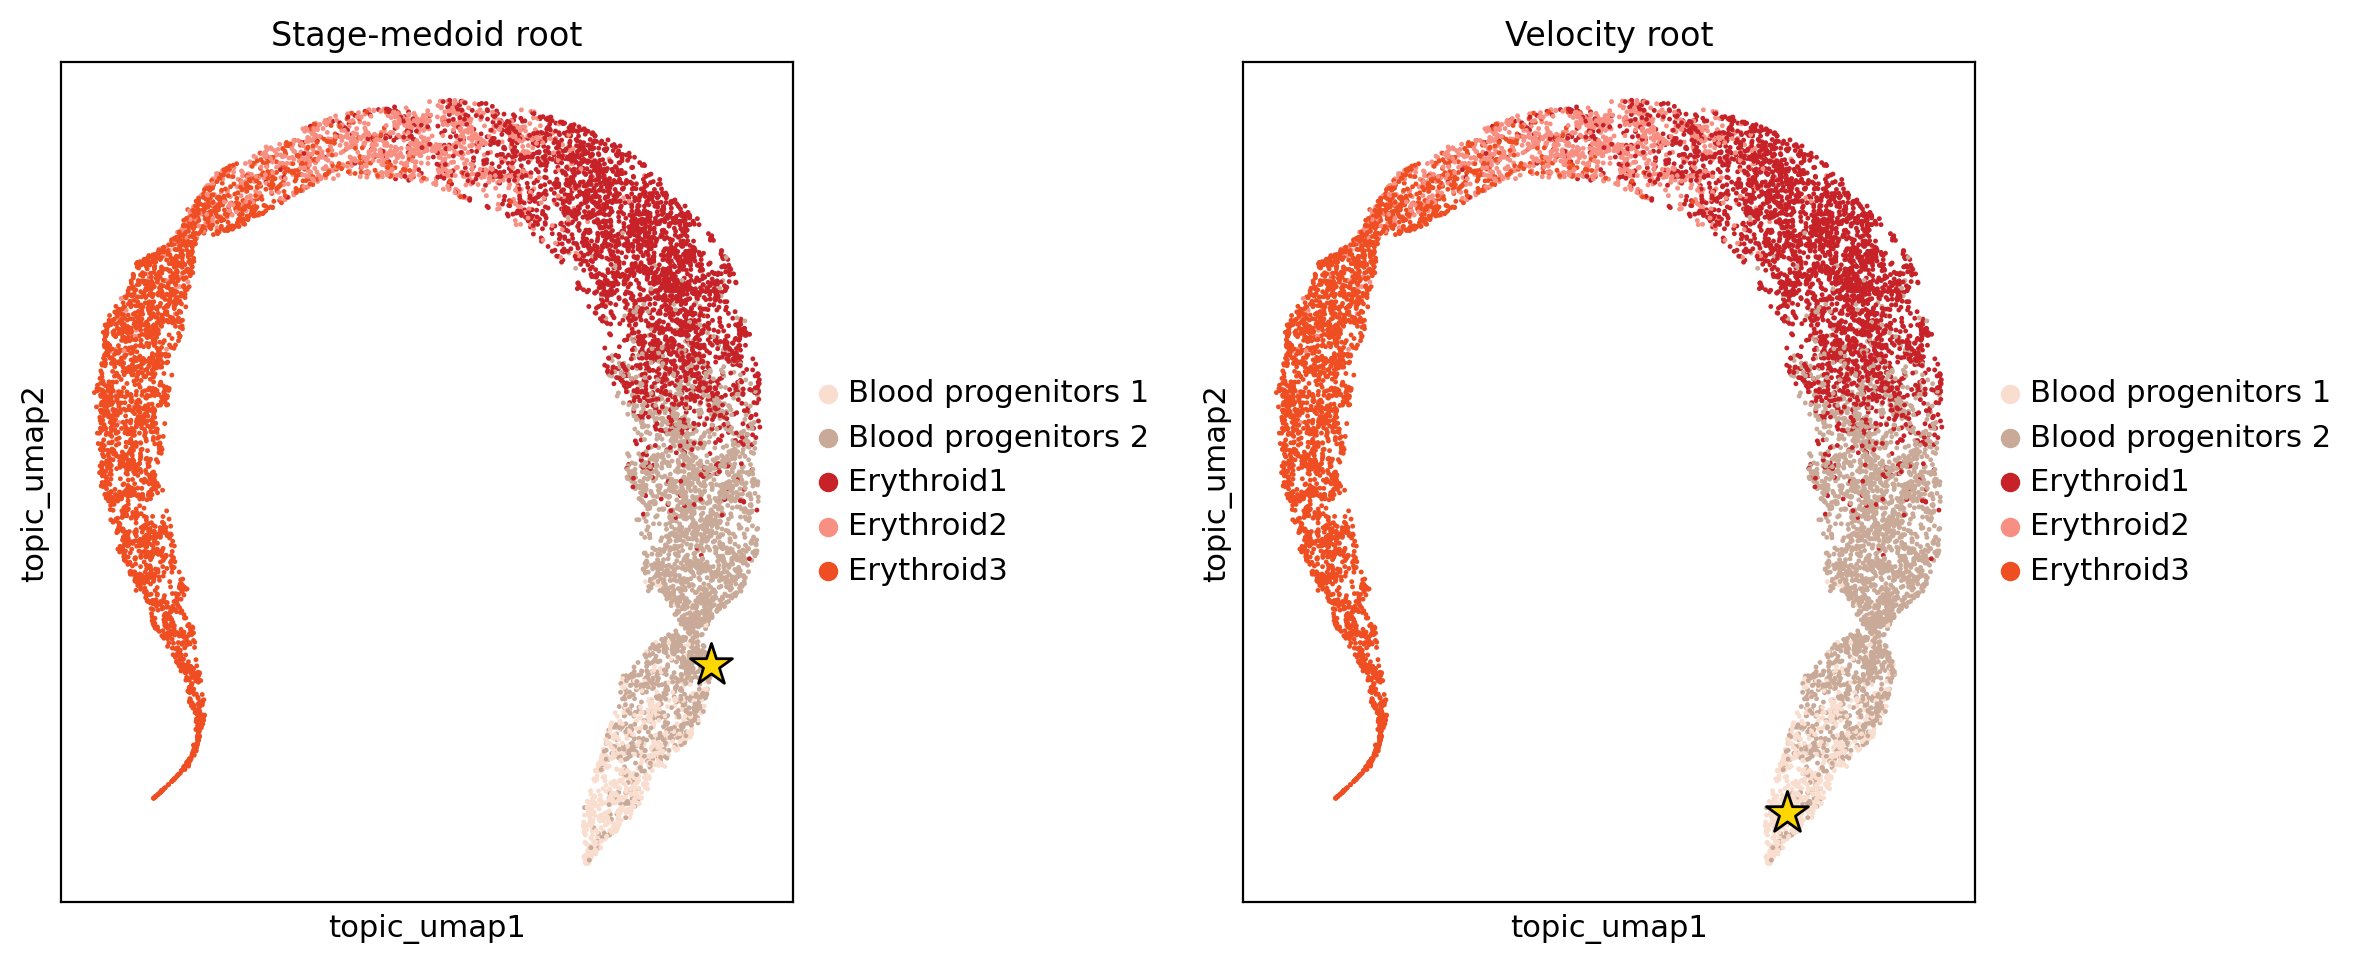

In [11]:
# Plot root locations on topic UMAP
umap = adata.obsm["topic_umap"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Stage-root plot
sc.pl.embedding(adata, basis="topic_umap", color="celltype", ax=axes[0], show=False, title="Stage-medoid root")
axes[0].scatter(umap[root_stage, 0], umap[root_stage, 1], marker="*", s=250, c="gold", edgecolors="black")

# Velocity-root plot (fallback to stage root if missing)
if "root_vel" in globals() and root_vel is not None:
    vel_root_to_plot = root_vel
    vel_title = "Velocity root"
else:
    vel_root_to_plot = root_stage
    vel_title = "Velocity root (fallback to stage root)"

sc.pl.embedding(adata, basis="topic_umap", color="celltype", ax=axes[1], show=False, title=vel_title)
axes[1].scatter(umap[vel_root_to_plot, 0], umap[vel_root_to_plot, 1], marker="*", s=250, c="gold", edgecolors="black")

plt.tight_layout()
plt.show()


In [12]:
# MST-based pseudotime (breaks loops on the kNN graph)
from scipy.sparse.csgraph import minimum_spanning_tree, shortest_path

# Use topic_neighbors distances
if "topic_neighbors_distances" not in adata.obsp:
    raise ValueError("topic_neighbors_distances not found; run sc.pp.neighbors with key_added='topic_neighbors' first")

dist = adata.obsp["topic_neighbors_distances"].copy()
# make symmetric for MST
try:
    dist = dist.maximum(dist.T)
except Exception:
    dist = (dist + dist.T) / 2

mst = minimum_spanning_tree(dist)
mst = mst + mst.T  # undirected

if "root_vel" in globals() and root_vel is not None:
    root_idx = root_vel
else:
    root_idx = root_stage

pt_raw = shortest_path(mst, directed=False, indices=root_idx)
pt_raw = np.asarray(pt_raw, dtype=float)

# Percentile-based mapping to uniform [0, 1]
mask = np.isfinite(pt_raw)
pt_uniform = np.full_like(pt_raw, np.nan, dtype=float)
if mask.sum() > 1:
    ranks = stats.rankdata(pt_raw[mask], method="average")
    pt_uniform[mask] = (ranks - 1) / (mask.sum() - 1)
elif mask.sum() == 1:
    pt_uniform[mask] = 0.0

adata.obs["mst_pseudotime_raw"] = pt_raw
adata.obs["mst_pseudotime"] = pt_uniform
print("MST pseudotime computed (percentile-mapped).")


MST pseudotime computed (percentile-mapped).


In [52]:
# Choose pseudotime representation for downstream analysis
# Options: "dpt_pseudotime_root_stage", "dpt_pseudotime_root_velocity", "velocity_pseudotime", "mst_pseudotime"
pseudotime_key = "mst_pseudotime"

if pseudotime_key not in adata.obs:
    raise ValueError(f"pseudotime_key '{pseudotime_key}' not found in adata.obs")

print(f"Using pseudotime: {pseudotime_key}")



Using pseudotime: mst_pseudotime


In [53]:
# Compute correlation between chosen pseudotime and velocity pseudotime
pt = adata.obs[pseudotime_key].values
vpt = adata.obs['velocity_pseudotime'].values

# Remove any NaN values
valid_mask = ~(np.isnan(pt) | np.isnan(vpt))
pt_valid = pt[valid_mask]
vpt_valid = vpt[valid_mask]

# Compute correlations
spearman_corr, spearman_p = spearmanr(pt_valid, vpt_valid)
pearson_corr, pearson_p = pearsonr(pt_valid, vpt_valid)

print("Pseudotime Correlation Analysis")
print("=" * 50)
print(f"Pseudotime key: {pseudotime_key}")
print(f"Spearman correlation: {spearman_corr:.4f} (p={spearman_p:.2e})")
print(f"Pearson correlation:  {pearson_corr:.4f} (p={pearson_p:.2e})")


Pseudotime Correlation Analysis
Pseudotime key: mst_pseudotime
Spearman correlation: 0.8214 (p=0.00e+00)
Pearson correlation:  0.8755 (p=0.00e+00)


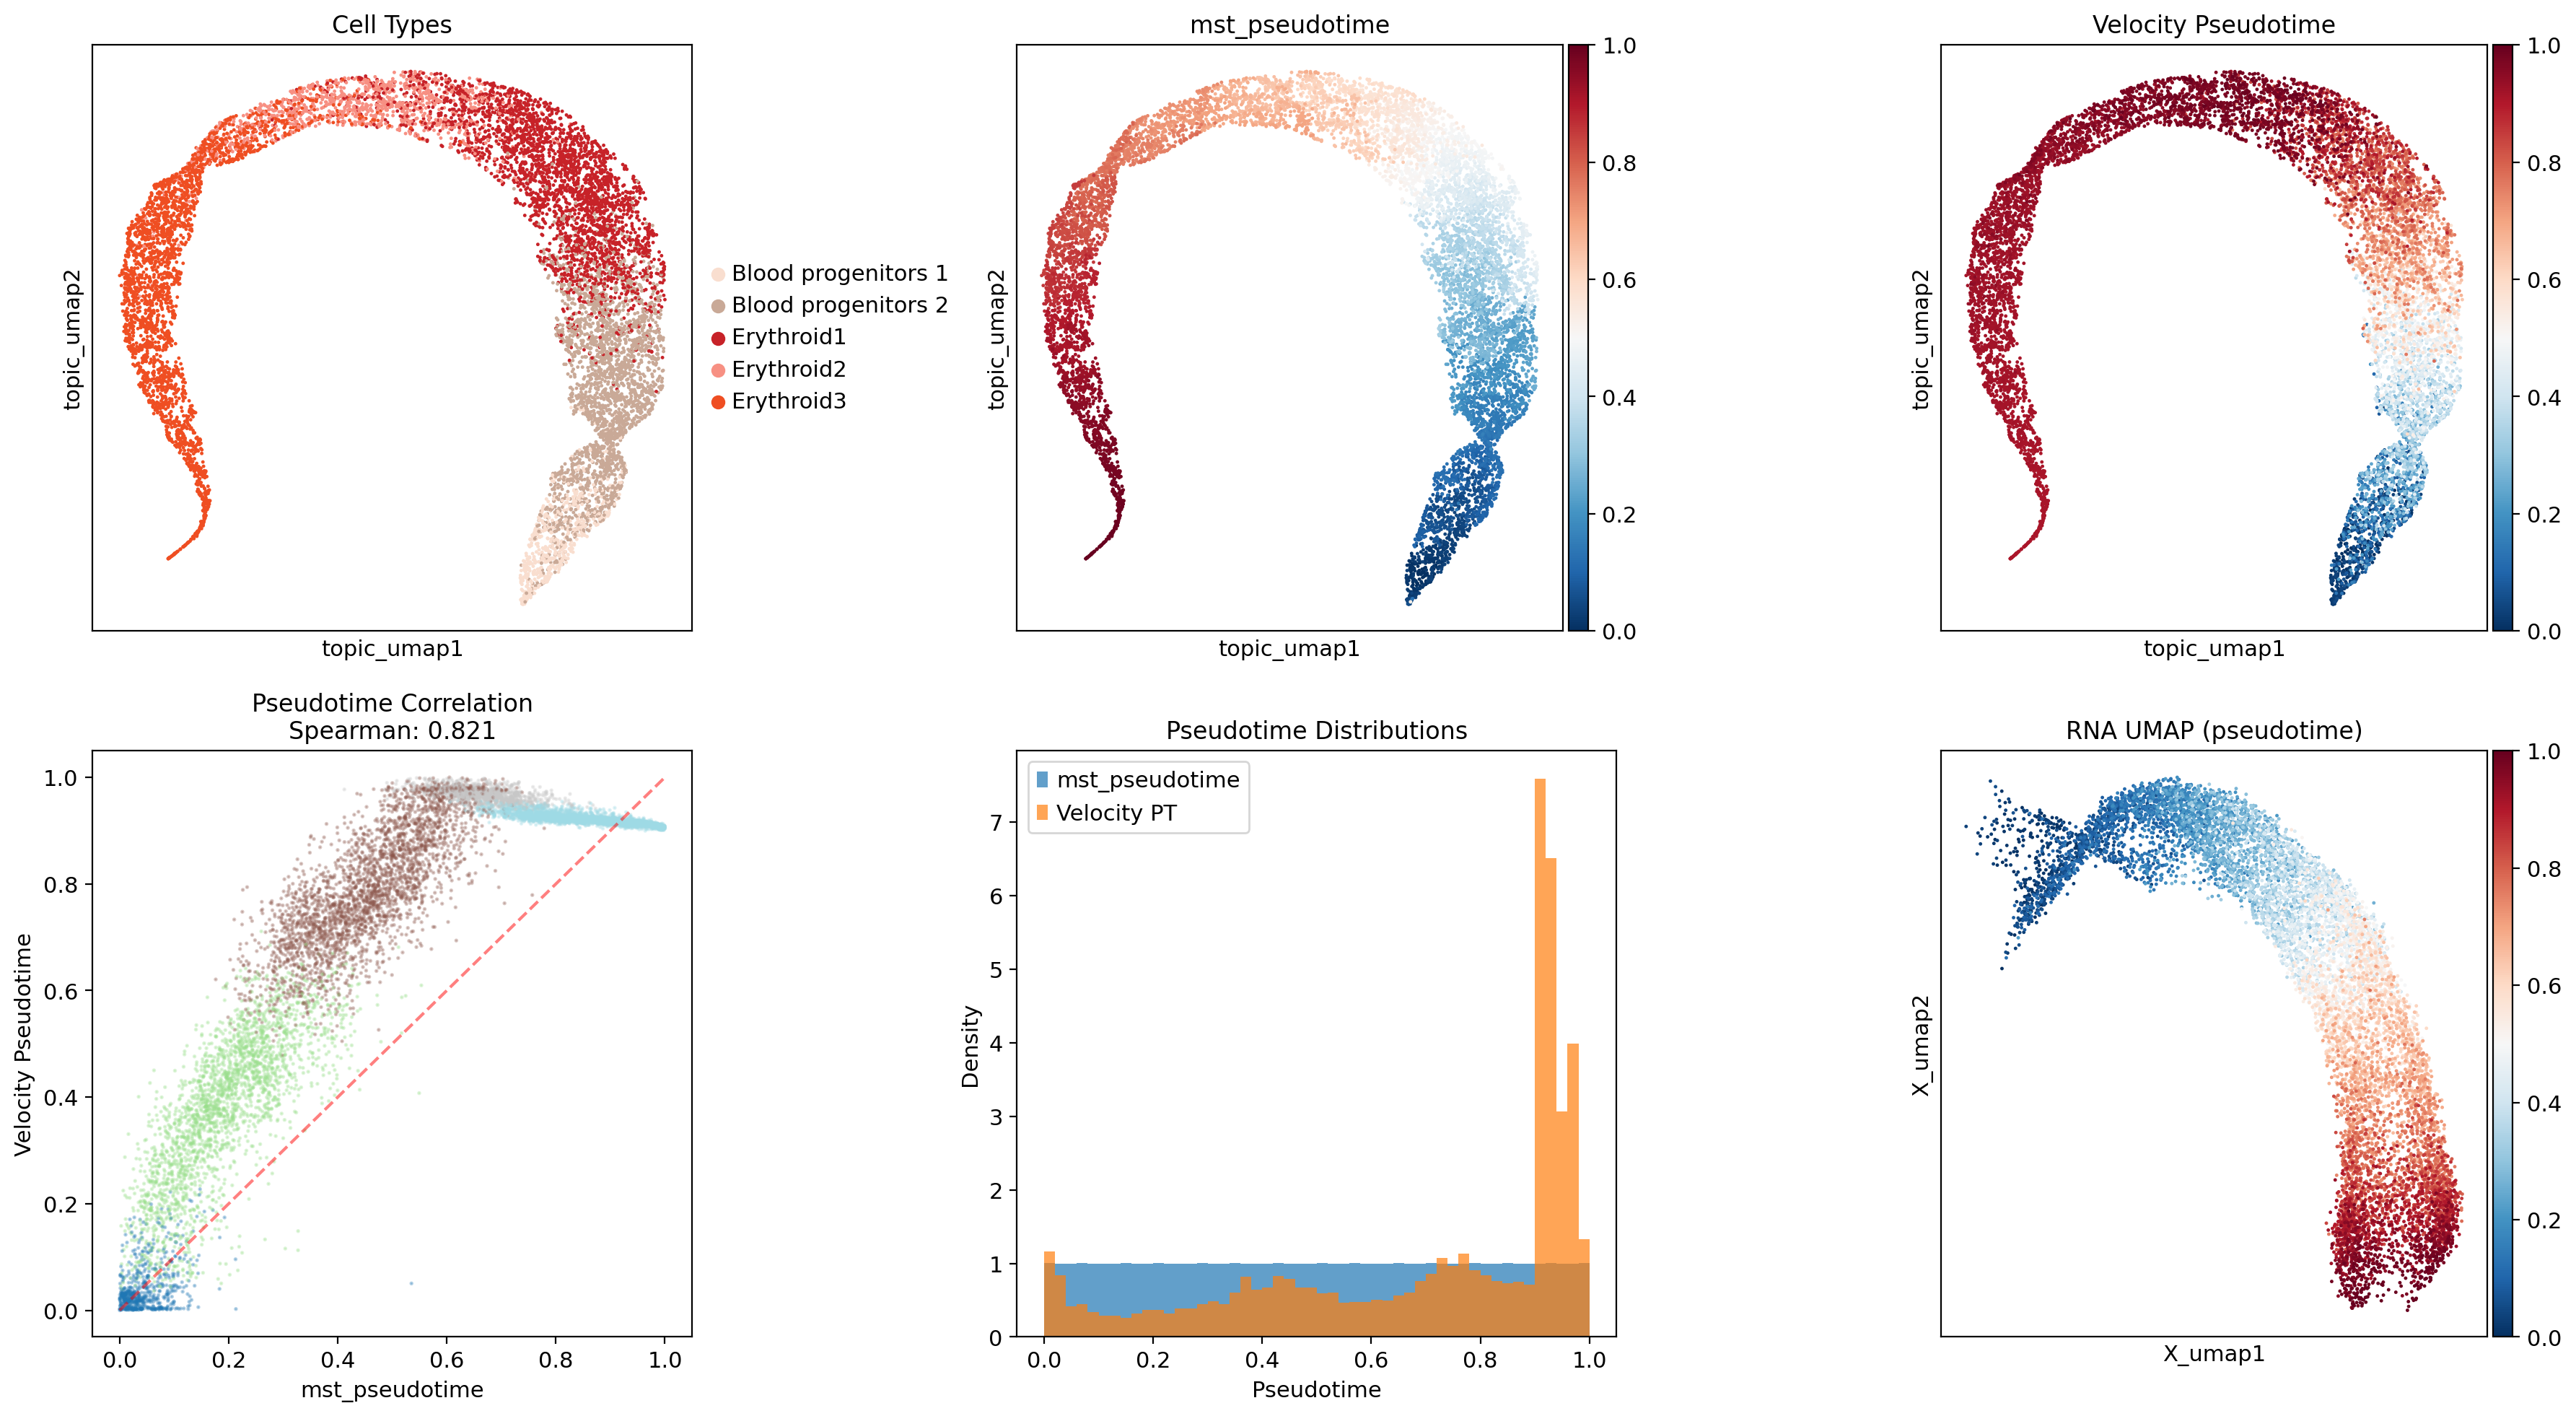

In [54]:
# Pseudotime visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: UMAP colored by cell type and pseudotimes
sc.pl.embedding(adata, basis="topic_umap", color="celltype", ax=axes[0, 0], show=False, title="Cell Types")
sc.pl.embedding(adata, basis="topic_umap", color=pseudotime_key, ax=axes[0, 1], show=False, title=f"{pseudotime_key}")
sc.pl.embedding(adata, basis="topic_umap", color="velocity_pseudotime", ax=axes[0, 2], show=False, title="Velocity Pseudotime")

# Row 2: Correlation scatter and histogram
ax = axes[1, 0]
scatter = ax.scatter(pt_valid, vpt_valid, alpha=0.3, s=1, c=adata.obs['celltype'].cat.codes[valid_mask], cmap='tab20')
ax.set_xlabel(pseudotime_key)
ax.set_ylabel("Velocity Pseudotime")
ax.set_title(f"Pseudotime Correlation\nSpearman: {spearman_corr:.3f}")
ax.plot([0, 1], [0, 1], 'r--', alpha=0.5)

axes[1, 1].hist(pt_valid, bins=50, alpha=0.7, label=pseudotime_key, density=True)
axes[1, 1].hist(vpt_valid, bins=50, alpha=0.7, label='Velocity PT', density=True)
axes[1, 1].set_xlabel("Pseudotime")
axes[1, 1].set_ylabel("Density")
axes[1, 1].legend()
axes[1, 1].set_title("Pseudotime Distributions")

# RNA UMAP colored by chosen pseudotime
if "X_umap" not in adata.obsm:
    print('Umap not found')
    sc.pp.pca(adata, n_comps=50)
    sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30, key_added="rna_neighbors")
    sc.tl.umap(adata, neighbors_key="rna_neighbors")
    adata.obsm["X_umap"] = adata.obsm["X_umap"].copy()

sc.pl.embedding(adata, basis="X_umap", color=pseudotime_key, ax=axes[1, 2], show=False, title="RNA UMAP (pseudotime)")

plt.tight_layout()
plt.show()


## 4. Gene Expression Derivatives via Topic Decomposition

### Mathematical Framework

In a topic model, gene expression can be decomposed as:
$$g = \theta \cdot \Phi^T$$

Taking the derivative with respect to pseudotime $t$:
$$\frac{dg}{dt} = \frac{d\theta}{dt} \cdot \Phi^T$$

**Implementation approach:**
1. Group cells by cell type
2. For each region, compute $\theta_{late}$ and $\theta_{early}$ at different pseudotime points
3. Estimate $\frac{d\theta}{dt} \approx \frac{\theta_{late} - \theta_{early}}{\Delta t}$
4. Compute gene derivatives: $\frac{dg}{dt} = \frac{d\theta}{dt} \cdot \Phi^T$
5. Rank genes by derivative magnitude to find drivers

In [55]:
def compute_gene_derivatives_by_celltype(
    theta: np.ndarray,
    phi: pd.DataFrame,
    pseudotime: np.ndarray,
    cell_types: np.ndarray,
    early_quantile: float = 0.25,
    late_quantile: float = 0.75,
) -> pd.DataFrame:
    """
    Compute gene expression derivatives for each cell type.
    
    Parameters
    ----------
    theta : np.ndarray
        Cell-topic proportions (n_cells x n_topics)
    phi : pd.DataFrame
        Topic-gene loadings (n_genes x n_topics)
    pseudotime : np.ndarray
        Pseudotime values for each cell
    cell_types : np.ndarray
        Cell type labels
    early_quantile : float
        Quantile threshold for "early" cells within each cell type
    late_quantile : float
        Quantile threshold for "late" cells within each cell type
        
    Returns
    -------
    pd.DataFrame
        Gene derivatives per cell type (n_genes x n_celltypes)
    """
    unique_celltypes = np.unique(cell_types)
    gene_names = phi.index
    n_genes = len(gene_names)
    
    # Convert phi to numpy (n_genes x n_topics)
    phi_array = phi.values
    
    results = {}
    
    for ct in unique_celltypes:
        ct_mask = cell_types == ct
        ct_pseudotime = pseudotime[ct_mask]
        ct_theta = theta[ct_mask]
        
        if len(ct_theta) < 10:  # Skip small populations
            continue
            
        # Define early and late cells within this cell type
        early_threshold = np.quantile(ct_pseudotime, early_quantile)
        late_threshold = np.quantile(ct_pseudotime, late_quantile)
        
        early_mask = ct_pseudotime <= early_threshold
        late_mask = ct_pseudotime >= late_threshold
        
        if early_mask.sum() < 3 or late_mask.sum() < 3:
            continue
        
        # Compute mean theta for early and late
        theta_early = ct_theta[early_mask].mean(axis=0)  # (n_topics,)
        theta_late = ct_theta[late_mask].mean(axis=0)    # (n_topics,)
        
        # Compute d_theta
        d_theta = theta_late - theta_early  # (n_topics,)
        
        # Compute gene derivatives: d_g = Phi @ d_theta
        # phi_array is (n_genes x n_topics), d_theta is (n_topics,)
        # Result is (n_genes,)
        d_gene = phi_array @ d_theta
        
        results[ct] = d_gene
    
    return pd.DataFrame(results, index=gene_names)


def compute_gene_derivatives_by_bins(
    theta: np.ndarray,
    phi: pd.DataFrame,
    pseudotime: np.ndarray,
    n_bins: int = 10,
) -> pd.DataFrame:
    """
    Compute gene derivatives across pseudotime bins.
    
    Returns derivatives for each bin transition (n_genes x n_bins-1).
    """
    # Create pseudotime bins
    bins = np.linspace(pseudotime.min(), pseudotime.max(), n_bins + 1)
    bin_labels = np.digitize(pseudotime, bins) - 1
    bin_labels = np.clip(bin_labels, 0, n_bins - 1)
    
    phi_array = phi.values
    gene_names = phi.index
    
    results = {}
    
    for i in range(n_bins - 1):
        early_mask = bin_labels == i
        late_mask = bin_labels == i + 1
        
        if early_mask.sum() < 3 or late_mask.sum() < 3:
            continue
        
        theta_early = theta[early_mask].mean(axis=0)
        theta_late = theta[late_mask].mean(axis=0)
        
        d_theta = theta_late - theta_early
        d_gene = phi_array @ d_theta
        
        results[f"bin_{i}_to_{i+1}"] = d_gene
    
    return pd.DataFrame(results, index=gene_names)

In [56]:
# Use chosen pseudotime representation
pseudotime = adata.obs[pseudotime_key].values

# Handle NaN values
valid_mask = ~np.isnan(pseudotime)
theta_valid = theta_best[valid_mask]
pseudotime_valid = pseudotime[valid_mask]
celltypes_valid = cell_types[valid_mask]

# Compute gene derivatives by cell type
gene_derivs_by_ct = compute_gene_derivatives_by_celltype(
    theta=theta_valid,
    phi=phi_mature,
    pseudotime=pseudotime_valid,
    cell_types=celltypes_valid,
    early_quantile=0.25,
    late_quantile=0.75,
)

print(f"Gene derivatives computed for {gene_derivs_by_ct.shape[1]} cell types")
print(f"Gene count: {gene_derivs_by_ct.shape[0]}")

# Compute gene derivatives across pseudotime bins
gene_derivs_by_bin = compute_gene_derivatives_by_bins(
    theta=theta_valid,
    phi=phi_mature,
    pseudotime=pseudotime_valid,
    n_bins=10,
)

print(f"Bin-based derivatives: {gene_derivs_by_bin.shape[1]} transitions")


Gene derivatives computed for 5 cell types
Gene count: 23622
Bin-based derivatives: 9 transitions


In [57]:
def get_top_genes_by_derivative(
    gene_derivs: pd.DataFrame,
    n_top: int = 20,
    direction: str = "both",  # "up", "down", or "both"
) -> dict:
    """
    Get top genes with largest derivatives for each column (cell type or bin).
    """
    results = {}
    
    for col in gene_derivs.columns:
        derivs = gene_derivs[col].dropna()
        
        if direction == "up":
            top_idx = derivs.nlargest(n_top).index
        elif direction == "down":
            top_idx = derivs.nsmallest(n_top).index
        else:  # both - by magnitude
            top_idx = derivs.abs().nlargest(n_top).index
        
        results[col] = [(gene, derivs[gene]) for gene in top_idx]
    
    return results

# Get top upregulated genes per cell type
top_up_genes = get_top_genes_by_derivative(gene_derivs_by_ct, n_top=15, direction="up")

# Get top downregulated genes per cell type  
top_down_genes = get_top_genes_by_derivative(gene_derivs_by_ct, n_top=15, direction="down")

# Print summary
print("Top Upregulated Genes per Cell Type (by derivative)")
print("=" * 60)
for ct, genes in list(top_up_genes.items())[:3]:  # Show first 3 cell types
    print(f"\n{ct}:")
    for gene, deriv in genes[:5]:
        print(f"  {gene}: {deriv:.4f}")

Top Upregulated Genes per Cell Type (by derivative)

Blood progenitors 1:
  Hba-a2: 0.0000
  Hbb-y: 0.0000
  Hbb-bs: 0.0000
  Hba-a1: 0.0000
  Hba-x: 0.0000

Blood progenitors 2:
  Hba-a2: 0.0000
  Hbb-y: 0.0000
  Hbb-bs: 0.0000
  Hba-a1: 0.0000
  Hba-x: 0.0000

Erythroid1:
  Hbb-bs: 0.0000
  Hba-a2: 0.0000
  Hbb-y: 0.0000
  Hba-a1: 0.0000
  Hba-x: 0.0000


## 5. Gene Derivative Visualizations

Visualize the gene derivatives:
1. Heatmap of top derivative genes per cell type
2. Gene expression dynamics along pseudotime
3. Topic contribution to gene derivatives

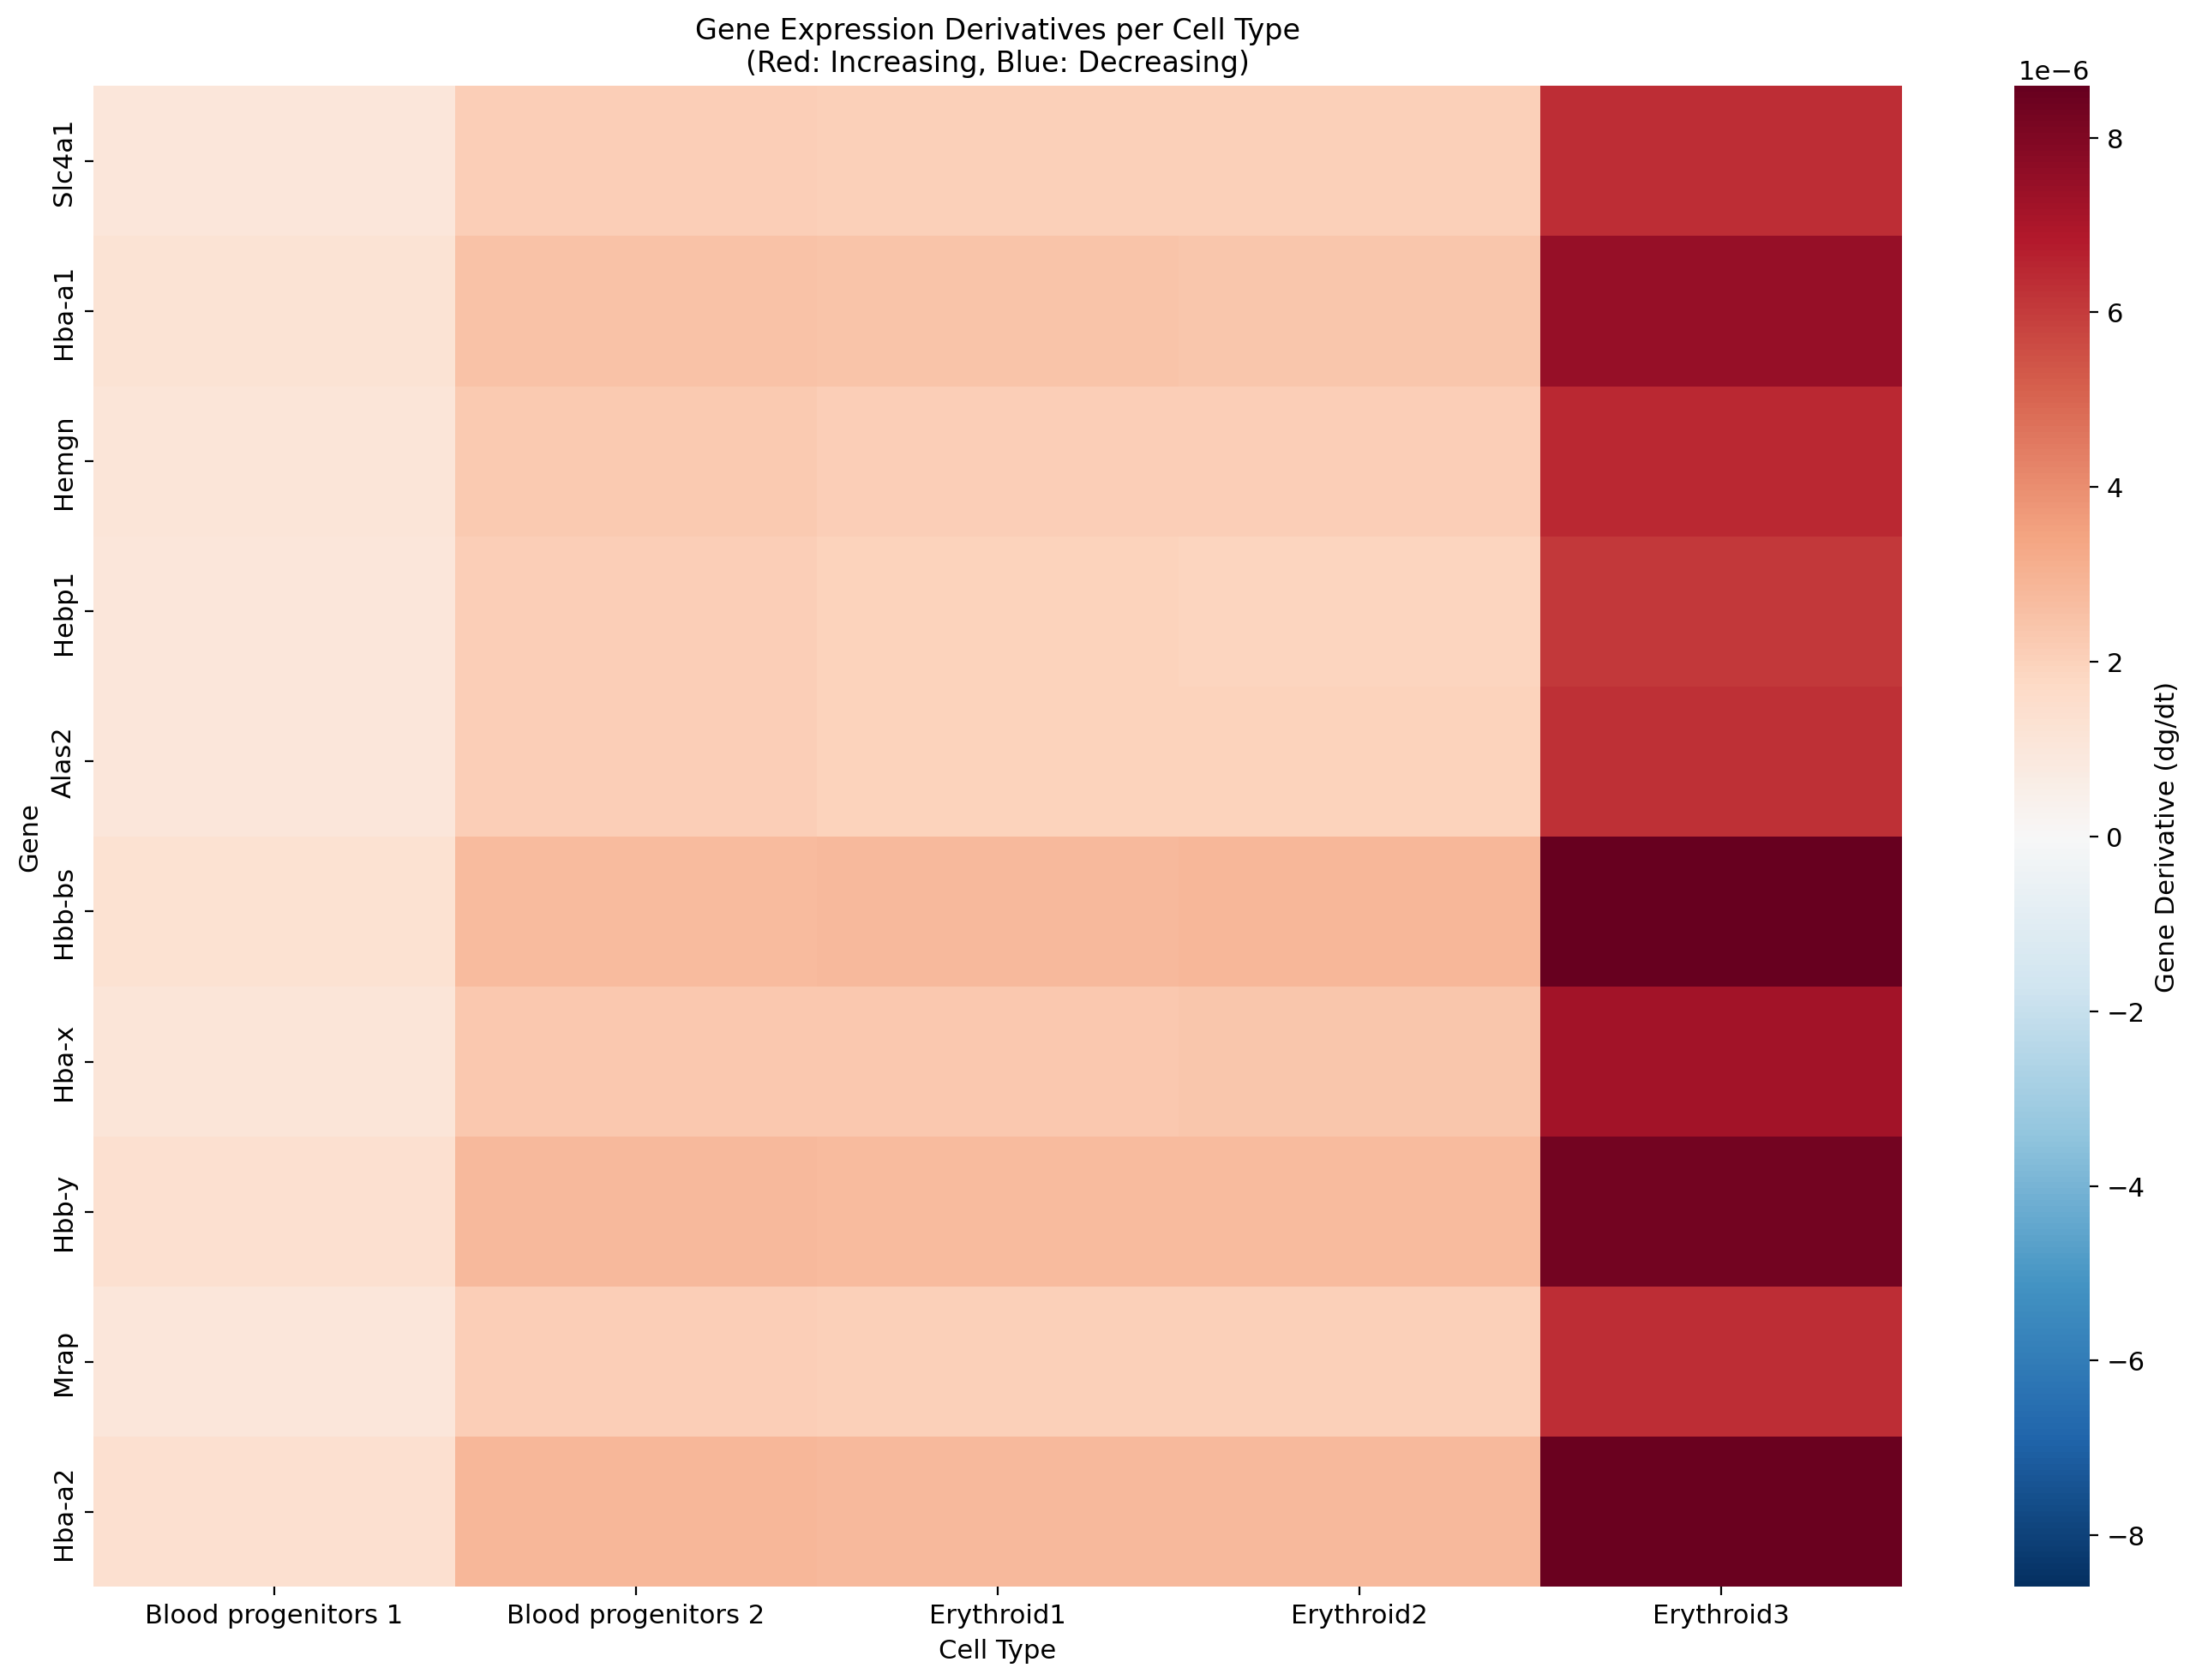

In [58]:
def create_derivative_heatmap(
    gene_derivs: pd.DataFrame,
    n_top: int = 10,
    figsize: tuple = (14, 10),
):
    """Create heatmap of top derivative genes per category."""
    # Get top genes by absolute derivative for each cell type
    all_top_genes = set()
    for col in gene_derivs.columns:
        top_genes = gene_derivs[col].abs().nlargest(n_top).index
        all_top_genes.update(top_genes)
    
    # Subset to top genes
    heatmap_data = gene_derivs.loc[list(all_top_genes)]
    
    # Create diverging colormap centered at 0
    fig, ax = plt.subplots(figsize=figsize)
    vmax = np.abs(heatmap_data.values).max()
    
    sns.heatmap(
        heatmap_data,
        cmap='RdBu_r',
        center=0,
        vmin=-vmax,
        vmax=vmax,
        ax=ax,
        cbar_kws={'label': 'Gene Derivative (dg/dt)'},
        xticklabels=True,
        yticklabels=True,
    )
    
    ax.set_xlabel("Cell Type")
    ax.set_ylabel("Gene")
    ax.set_title("Gene Expression Derivatives per Cell Type\n(Red: Increasing, Blue: Decreasing)")
    
    plt.tight_layout()
    return fig

fig = create_derivative_heatmap(gene_derivs_by_ct, n_top=10)
plt.show()

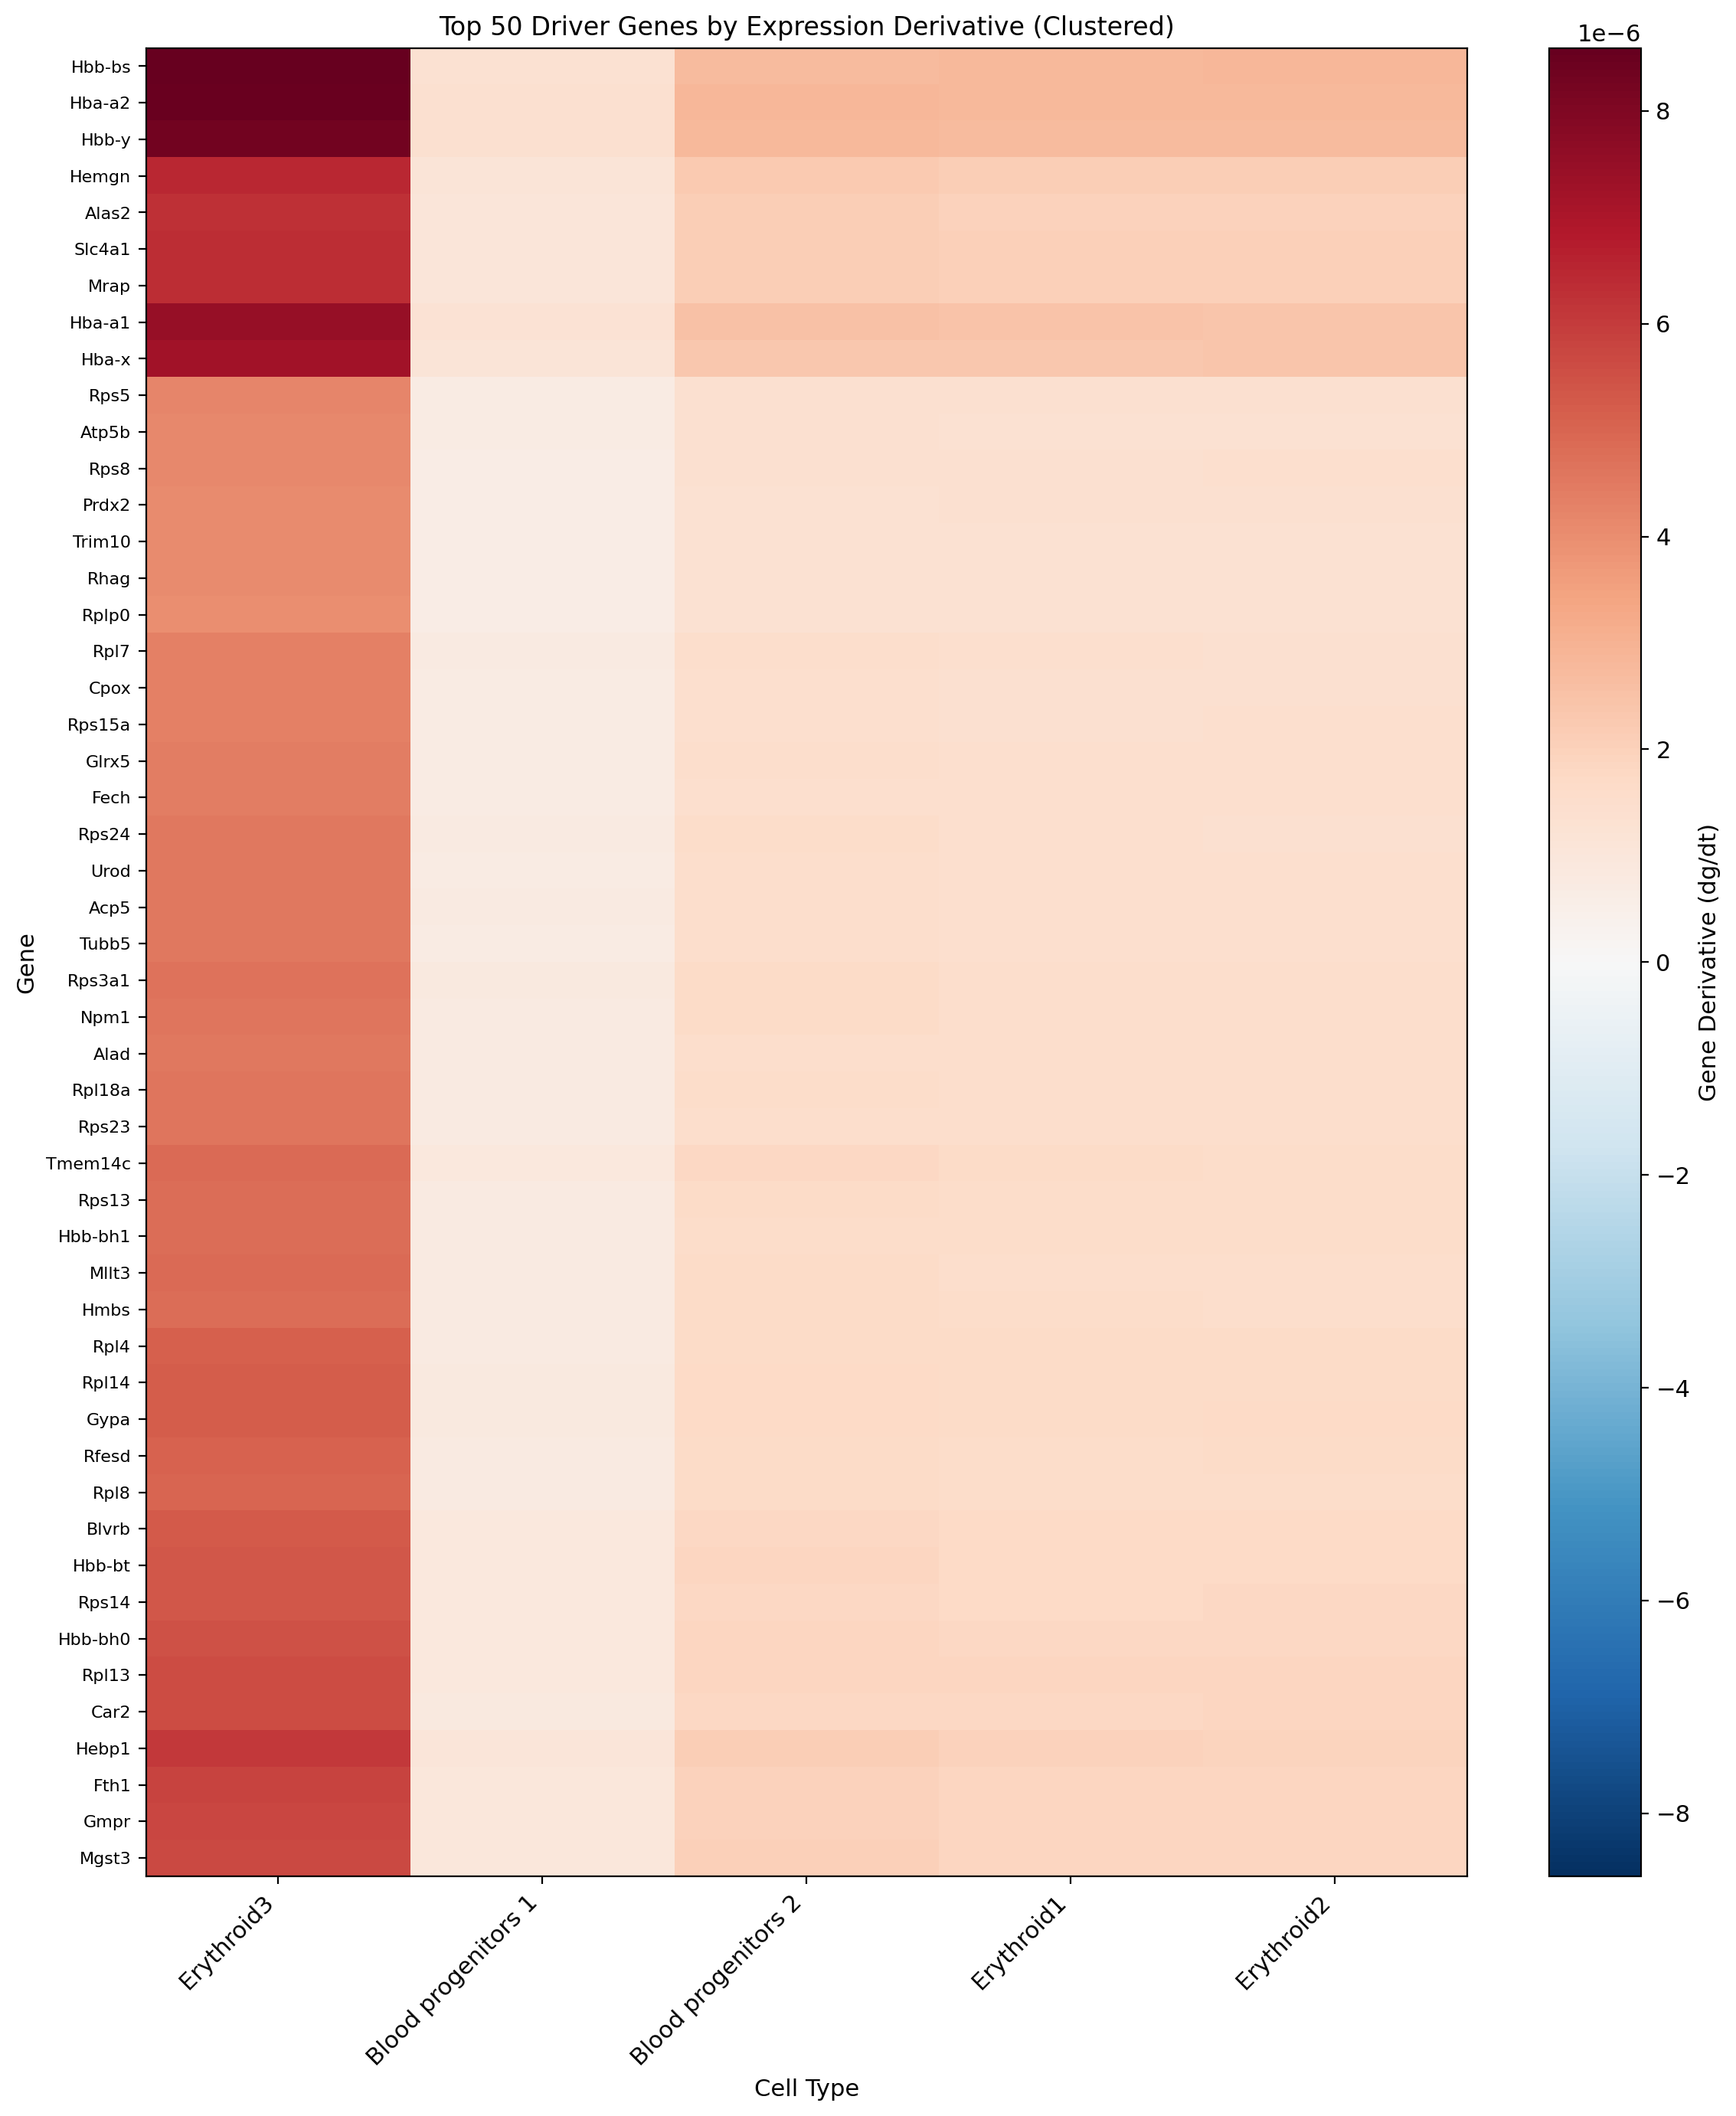

In [59]:
# Create a more sophisticated clustered heatmap
# Get top 50 genes by max absolute derivative across cell types
max_abs_deriv = gene_derivs_by_ct.abs().max(axis=1)
top_genes = max_abs_deriv.nlargest(50).index

heatmap_data = gene_derivs_by_ct.loc[top_genes].copy()

# Cluster genes
gene_linkage = hierarchy.linkage(heatmap_data.values, method='ward')
gene_order = hierarchy.leaves_list(gene_linkage)

# Cluster cell types
ct_linkage = hierarchy.linkage(heatmap_data.values.T, method='ward')
ct_order = hierarchy.leaves_list(ct_linkage)

# Reorder data
heatmap_ordered = heatmap_data.iloc[gene_order, ct_order]

# Plot
fig, ax = plt.subplots(figsize=(12, 14))
vmax = np.abs(heatmap_ordered.values).max()

im = ax.imshow(
    heatmap_ordered.values,
    cmap='RdBu_r',
    aspect='auto',
    vmin=-vmax,
    vmax=vmax,
)

ax.set_xticks(range(len(heatmap_ordered.columns)))
ax.set_xticklabels(heatmap_ordered.columns, rotation=45, ha='right')
ax.set_yticks(range(len(heatmap_ordered.index)))
ax.set_yticklabels(heatmap_ordered.index, fontsize=8)

plt.colorbar(im, ax=ax, label='Gene Derivative (dg/dt)')
ax.set_title("Top 50 Driver Genes by Expression Derivative (Clustered)")
ax.set_xlabel("Cell Type")
ax.set_ylabel("Gene")

plt.tight_layout()
plt.show()

Plotting expression trajectories for top genes in Blood progenitors 1


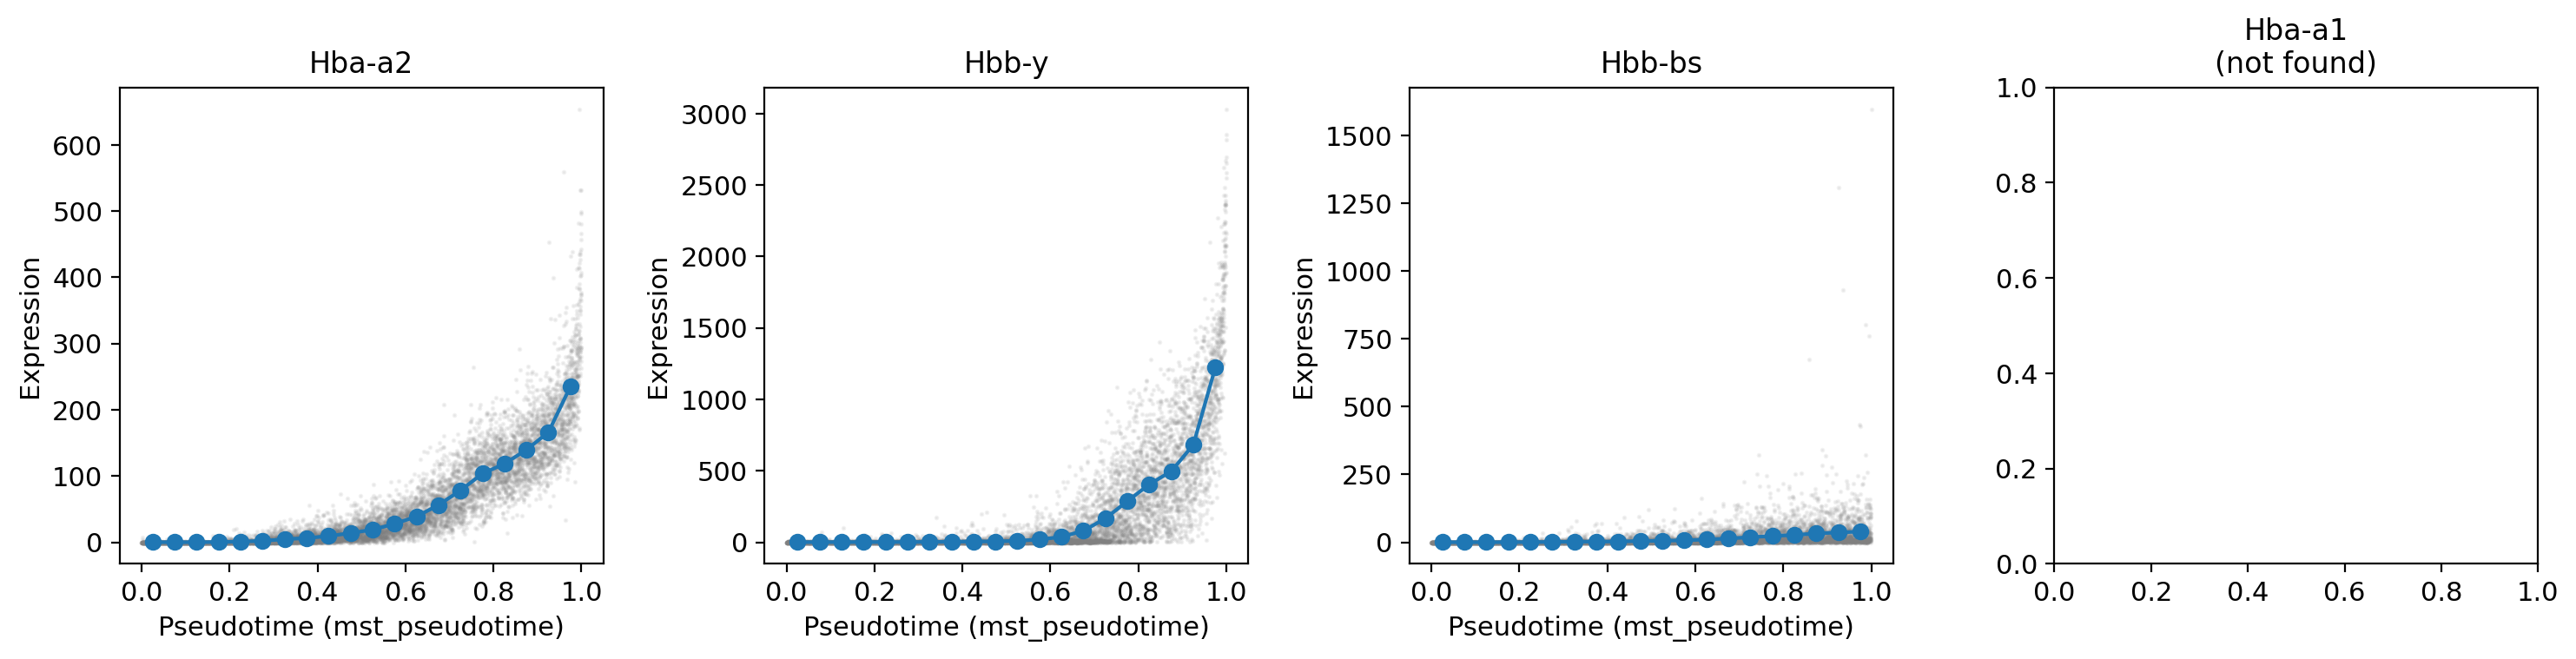

In [60]:
def plot_gene_expression_trajectory(
    adata,
    genes: list,
    pseudotime_key: str | None = None,
    n_bins: int = 20,
    figsize: tuple = (15, 4),
):
    """Plot gene expression along pseudotime."""
    fig, axes = plt.subplots(1, len(genes), figsize=figsize)
    if len(genes) == 1:
        axes = [axes]
    
    pt_key = pseudotime_key or globals().get('pseudotime_key', 'dpt_pseudotime_root_stage')
    pt = adata.obs[pt_key].values
    valid_mask = ~np.isnan(pt)
    
    # Get expression data (spliced layer)
    X = adata.layers['spliced']
    if hasattr(X, 'toarray'):
        X = X.toarray()
    
    for ax, gene in zip(axes, genes):
        if gene not in adata.var_names:
            ax.set_title(f"{gene}\n(not found)")
            continue
            
        gene_idx = list(adata.var_names).index(gene)
        expr = X[valid_mask, gene_idx]
        pt_valid = pt[valid_mask]
        
        # Bin and compute mean expression
        bins = np.linspace(pt_valid.min(), pt_valid.max(), n_bins + 1)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        bin_means = []
        bin_stds = []
        
        for i in range(n_bins):
            mask = (pt_valid >= bins[i]) & (pt_valid < bins[i+1])
            if mask.sum() > 0:
                bin_means.append(expr[mask].mean())
                bin_stds.append(expr[mask].std() / np.sqrt(mask.sum()))
            else:
                bin_means.append(np.nan)
                bin_stds.append(np.nan)
        
        ax.errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o-', capsize=3)
        ax.scatter(pt_valid, expr, alpha=0.1, s=1, c='gray')
        ax.set_xlabel(f'Pseudotime ({pt_key})')
        ax.set_ylabel("Expression")
        ax.set_title(gene)
    
    plt.tight_layout()
    return fig

# Plot top derivative genes
# Select a cell type with interesting dynamics
if len(top_up_genes) > 0:
    selected_ct = list(top_up_genes.keys())[0]  # First cell type
    top_genes_to_plot = [g[0] for g in top_up_genes[selected_ct][:4]]
    
    print(f"Plotting expression trajectories for top genes in {selected_ct}")
    fig = plot_gene_expression_trajectory(adata, top_genes_to_plot, pseudotime_key=pseudotime_key)
    plt.show()


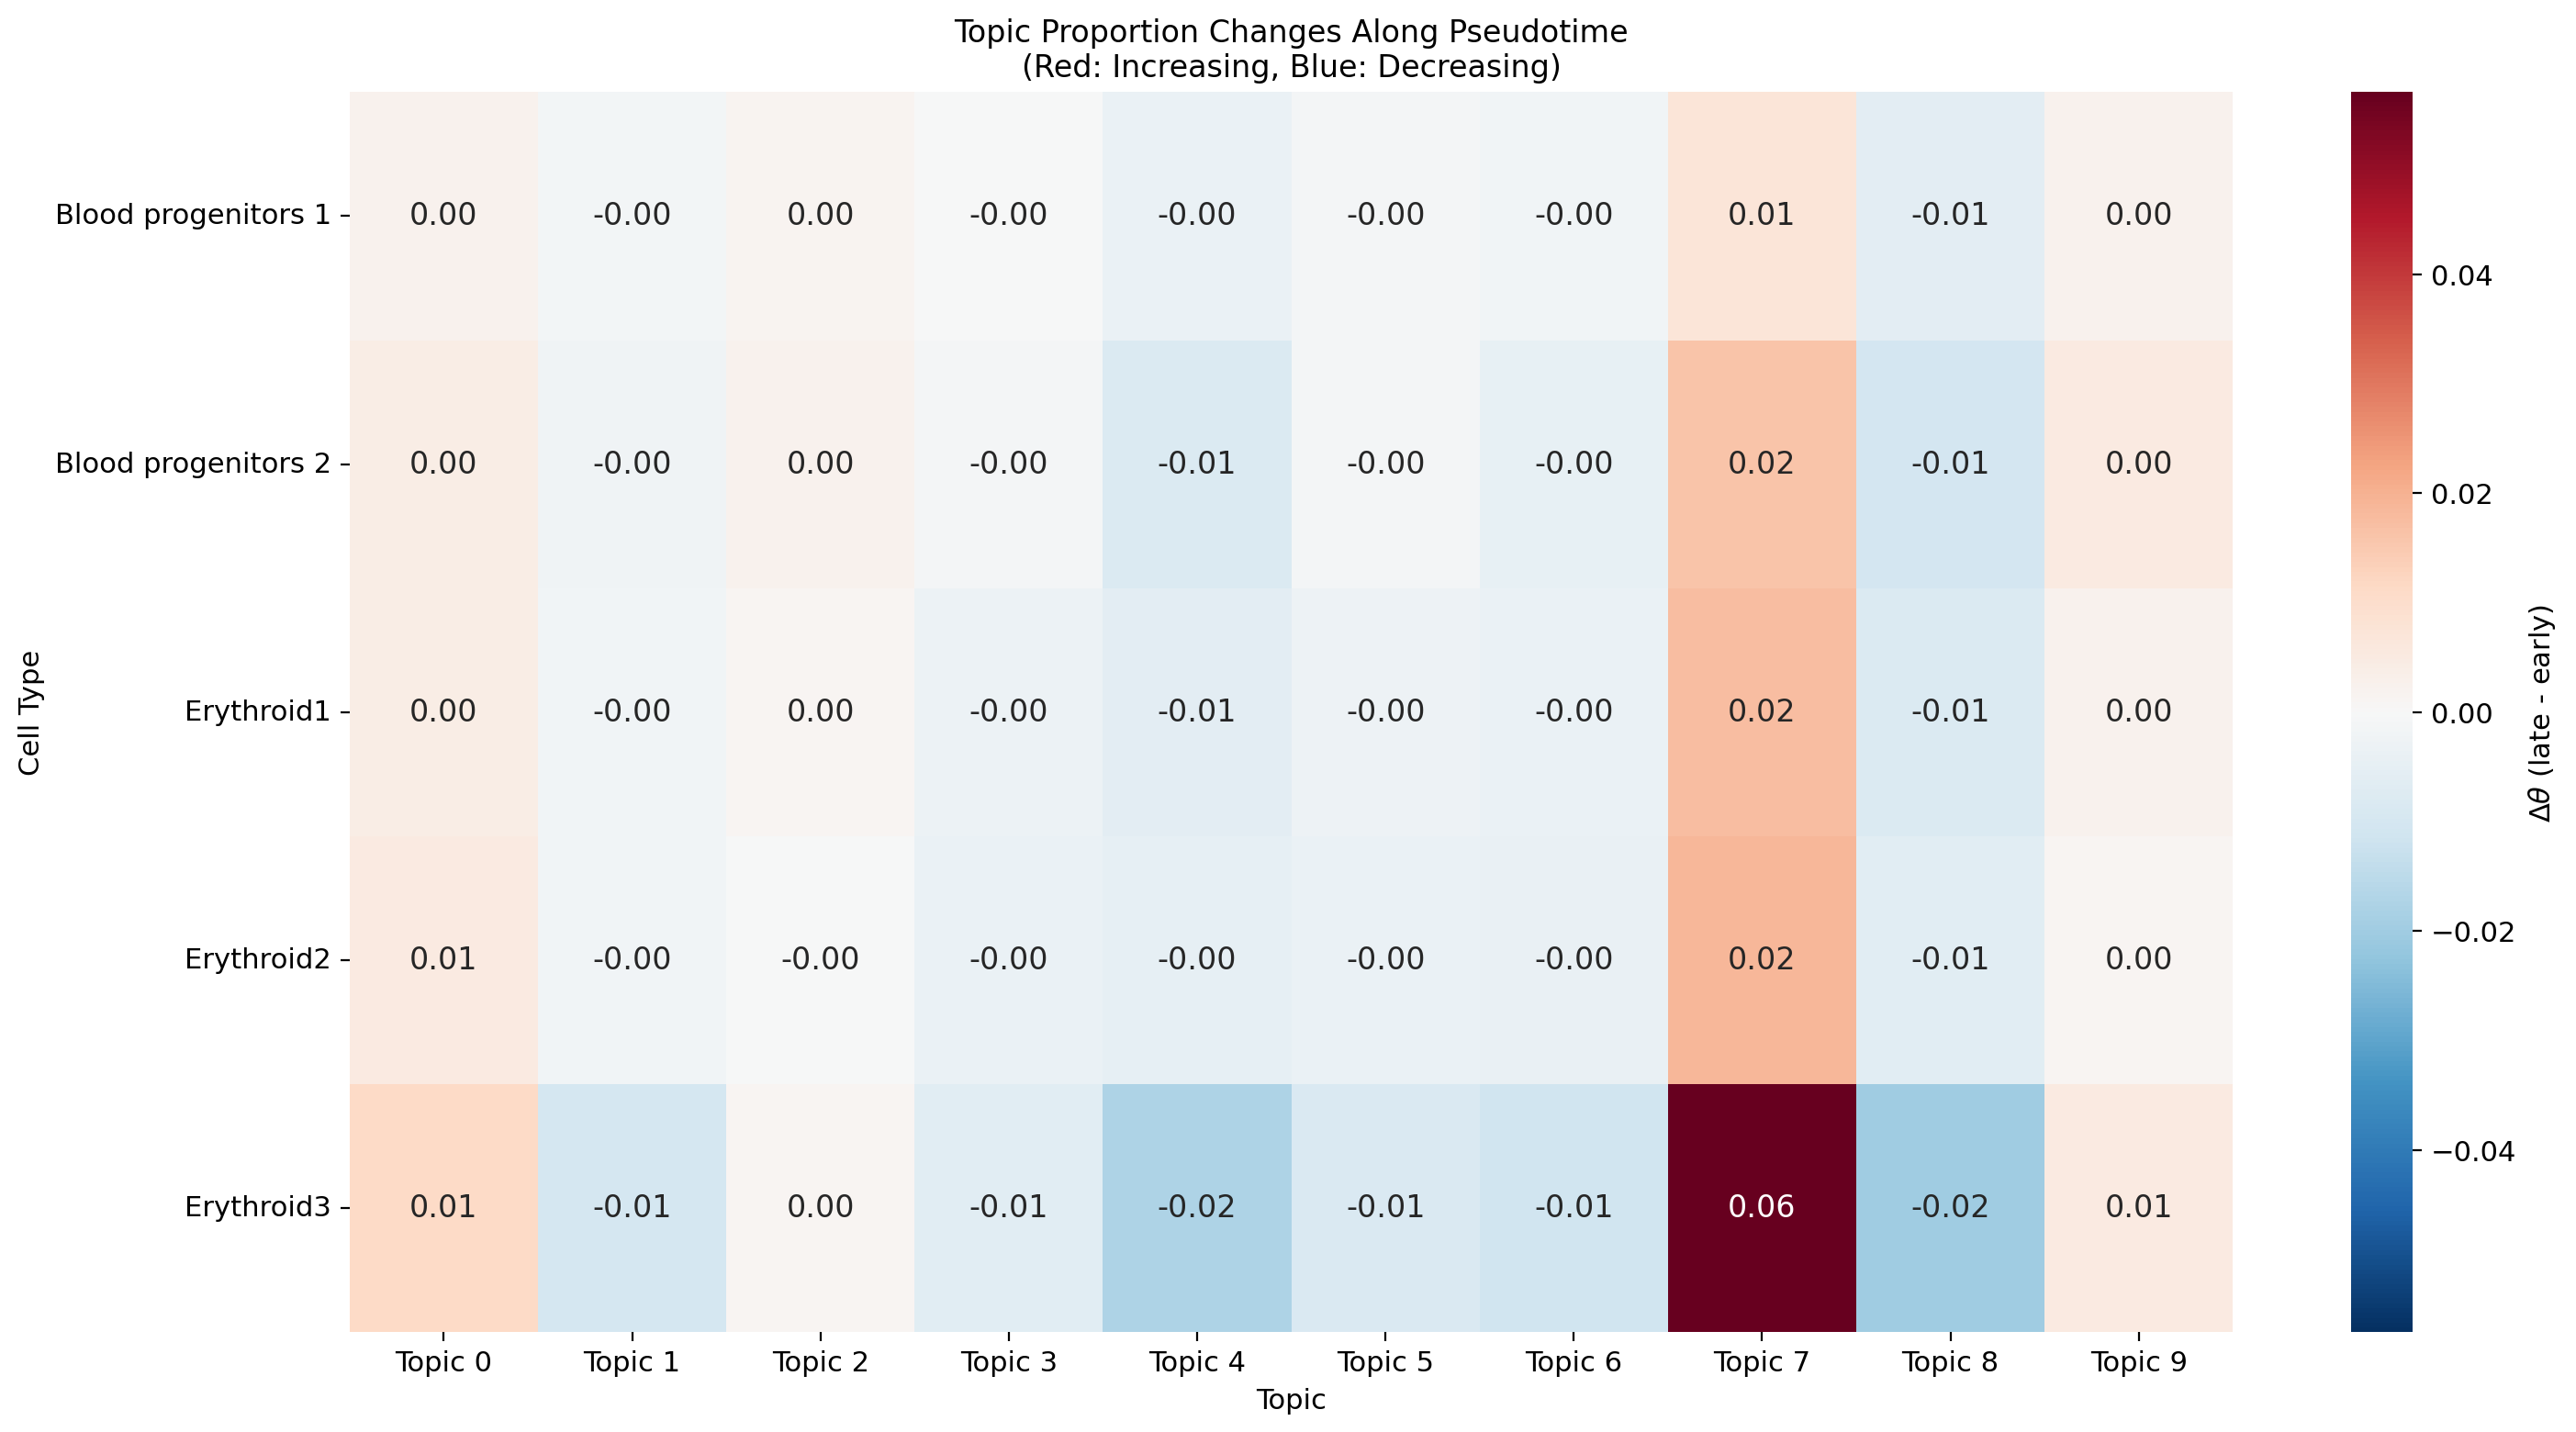


Topic changes summary:
                     Topic 0  Topic 1  Topic 2  Topic 3  Topic 4  Topic 5  \
Blood progenitors 1    0.003   -0.001    0.002   -0.000   -0.004   -0.001   
Blood progenitors 2    0.004   -0.002    0.002   -0.001   -0.008   -0.001   
Erythroid1             0.004   -0.002    0.001   -0.003   -0.006   -0.003   
Erythroid2             0.005   -0.002   -0.000   -0.004   -0.005   -0.004   
Erythroid3             0.011   -0.010    0.001   -0.006   -0.018   -0.009   

                     Topic 6  Topic 7  Topic 8  Topic 9  
Blood progenitors 1   -0.002    0.007   -0.006    0.003  
Blood progenitors 2   -0.004    0.016   -0.011    0.005  
Erythroid1            -0.004    0.017   -0.008    0.003  
Erythroid2            -0.004    0.019   -0.006    0.001  
Erythroid3            -0.012    0.057   -0.020    0.005  


In [61]:
def analyze_topic_contributions(
    theta: np.ndarray,
    pseudotime: np.ndarray,
    cell_types: np.ndarray,
    n_topics: int,
    figsize: tuple = (15, 8),
):
    """Analyze which topics change most along pseudotime per cell type."""
    valid_mask = ~np.isnan(pseudotime)
    theta_valid = theta[valid_mask]
    pt_valid = pseudotime[valid_mask]
    ct_valid = cell_types[valid_mask]
    
    unique_cts = np.unique(ct_valid)
    
    # Compute topic change per cell type
    topic_changes = {}
    
    for ct in unique_cts:
        ct_mask = ct_valid == ct
        if ct_mask.sum() < 20:
            continue
            
        ct_pt = pt_valid[ct_mask]
        ct_theta = theta_valid[ct_mask]
        
        early_q = np.quantile(ct_pt, 0.25)
        late_q = np.quantile(ct_pt, 0.75)
        
        early_theta = ct_theta[ct_pt <= early_q].mean(axis=0)
        late_theta = ct_theta[ct_pt >= late_q].mean(axis=0)
        
        topic_changes[ct] = late_theta - early_theta
    
    # Create heatmap
    changes_df = pd.DataFrame(topic_changes).T
    changes_df.columns = [f"Topic {i}" for i in range(n_topics)]
    
    fig, ax = plt.subplots(figsize=figsize)
    vmax = np.abs(changes_df.values).max()
    
    sns.heatmap(
        changes_df,
        cmap='RdBu_r',
        center=0,
        vmin=-vmax,
        vmax=vmax,
        ax=ax,
        annot=True,
        fmt='.2f',
        cbar_kws={'label': r'$\Delta\theta$ (late - early)'},
    )
    
    ax.set_xlabel("Topic")
    ax.set_ylabel("Cell Type")
    ax.set_title("Topic Proportion Changes Along Pseudotime\n(Red: Increasing, Blue: Decreasing)")
    
    plt.tight_layout()
    return fig, changes_df

fig, topic_change_df = analyze_topic_contributions(
    theta_best, pseudotime, cell_types, n_topics=n_topics
)
plt.show()

print("\nTopic changes summary:")
print(topic_change_df.round(3))

## 6. Summary: Top Driver Genes per Cell Type

Comprehensive table of genes with largest expression derivatives, 
representing potential drivers of cell type transitions.

In [62]:
def create_driver_gene_summary(
    gene_derivs: pd.DataFrame,
    n_top: int = 10,
) -> pd.DataFrame:
    """Create summary table of top driver genes per cell type."""
    rows = []
    
    for ct in gene_derivs.columns:
        derivs = gene_derivs[ct].dropna()
        
        # Top upregulated
        up_genes = derivs.nlargest(n_top)
        for gene, deriv in up_genes.items():
            rows.append({
                'cell_type': ct,
                'gene': gene,
                'derivative': deriv,
                'direction': 'up',
                'rank': list(up_genes.index).index(gene) + 1,
            })
        
        # Top downregulated
        down_genes = derivs.nsmallest(n_top)
        for gene, deriv in down_genes.items():
            rows.append({
                'cell_type': ct,
                'gene': gene,
                'derivative': deriv,
                'direction': 'down',
                'rank': list(down_genes.index).index(gene) + 1,
            })
    
    return pd.DataFrame(rows)

summary_df = create_driver_gene_summary(gene_derivs_by_ct, n_top=10)

# Display pivot table
print("Top 10 Upregulated Genes per Cell Type")
print("=" * 80)
up_pivot = summary_df[summary_df['direction'] == 'up'].pivot(
    index='rank', columns='cell_type', values='gene'
)
print(up_pivot.to_string())

print("\n\nTop 10 Downregulated Genes per Cell Type")
print("=" * 80)
down_pivot = summary_df[summary_df['direction'] == 'down'].pivot(
    index='rank', columns='cell_type', values='gene'
)
print(down_pivot.to_string())

Top 10 Upregulated Genes per Cell Type
cell_type Blood progenitors 1 Blood progenitors 2 Erythroid1 Erythroid2 Erythroid3
rank                                                                              
1                      Hba-a2              Hba-a2     Hbb-bs     Hbb-bs     Hbb-bs
2                       Hbb-y               Hbb-y     Hba-a2     Hba-a2     Hba-a2
3                      Hbb-bs              Hbb-bs      Hbb-y      Hbb-y      Hbb-y
4                      Hba-a1              Hba-a1     Hba-a1     Hba-a1     Hba-a1
5                       Hba-x               Hba-x      Hba-x      Hba-x      Hba-x
6                       Hemgn               Hemgn      Hemgn      Hemgn      Hemgn
7                       Hebp1                Mrap       Mrap       Mrap     Slc4a1
8                      Slc4a1               Alas2     Slc4a1     Slc4a1       Mrap
9                       Alas2              Slc4a1      Alas2      Alas2      Alas2
10                       Mrap               Hebp

In [63]:
# Save results
output_dir = MODELS_DIR / "analysis_results"
output_dir.mkdir(exist_ok=True)

# Save gene derivatives
gene_derivs_by_ct.to_csv(output_dir / "gene_derivatives_by_celltype.csv")
gene_derivs_by_bin.to_csv(output_dir / "gene_derivatives_by_bin.csv")

# Save summary table
summary_df.to_csv(output_dir / "driver_genes_summary.csv", index=False)

# Save pseudotime comparison
stage_pt = (
    adata.obs["dpt_pseudotime_root_stage"].values
    if "dpt_pseudotime_root_stage" in adata.obs
    else np.full(adata.n_obs, np.nan)
)
vel_pt = (
    adata.obs["dpt_pseudotime_root_velocity"].values
    if "dpt_pseudotime_root_velocity" in adata.obs
    else np.full(adata.n_obs, np.nan)
)

mst_pt = (
    adata.obs["mst_pseudotime"].values
    if "mst_pseudotime" in adata.obs
    else np.full(adata.n_obs, np.nan)
)

mst_raw_pt = (
    adata.obs["mst_pseudotime_raw"].values
    if "mst_pseudotime_raw" in adata.obs
    else np.full(adata.n_obs, np.nan)
)

pseudotime_df = pd.DataFrame({
    'cell_barcode': adata.obs_names[valid_mask],
    'celltype': celltypes_valid,
    'pseudotime_key': pseudotime_key,
    'pseudotime': pseudotime_valid,
    'velocity_pseudotime': adata.obs['velocity_pseudotime'].values[valid_mask],
    'dpt_pseudotime_root_stage': stage_pt[valid_mask],
    'dpt_pseudotime_root_velocity': vel_pt[valid_mask],
    'mst_pseudotime': mst_pt[valid_mask],
    'mst_pseudotime_raw': mst_raw_pt[valid_mask],
})
pseudotime_df.to_csv(output_dir / "pseudotime_comparison.csv", index=False)

# Save topic changes
topic_change_df.to_csv(output_dir / "topic_changes_by_celltype.csv")

# Save model selection results
df_sorted.to_csv(output_dir / "model_selection_results.csv", index=False)

print(f"Results saved to: {output_dir}")
print("\nSaved files:")
for f in output_dir.iterdir():
    print(f"  - {f.name}")




Results saved to: /data/omics_topic_models/gastrulation/analysis_results

Saved files:
  - gene_derivatives_by_celltype.csv
  - gene_derivatives_by_bin.csv
  - driver_genes_summary.csv
  - pseudotime_comparison.csv
  - topic_changes_by_celltype.csv
  - model_selection_results.csv


## 7. Summary and Conclusions

### Key Findings

1. **Model Selection**: Best model selected based on kNN cell type classification accuracy

2. **Pseudotime Comparison**:
   - DPT in topic space and velocity pseudotime show correlation
   - Topic-based DPT captures global developmental structure
   - Velocity pseudotime reflects local transcriptional dynamics

3. **Gene Derivative Analysis**:
   - Novel method to identify driver genes using topic model decomposition
   - Gene expression derivative: $\frac{dg}{dt} = \frac{d\theta}{dt} \cdot \Phi^T$
   - Identifies genes driving cell type transitions along pseudotime

### Advantages of Topic-Based Gene Derivatives

1. **Interpretability**: Gene changes decomposed through topics
2. **Noise reduction**: Topic model provides regularization
3. **Multi-scale analysis**: Can analyze at cell type or pseudotime bin level
4. **Integration-ready**: Works with multimodal topic models (spliced + unspliced)

In [ ]:
print("Analysis complete!")
print(f"\nBest model: {best_model_name}")
print(f"DPT-Velocity correlation: {spearman_corr:.3f}")
print(f"Gene derivatives computed for {gene_derivs_by_ct.shape[1]} cell types")
print(f"Results saved to: {output_dir}")

Analysis complete!

Best model: prior_logistic_normal_weight_equal_learnable_disp_global
DPT-Velocity correlation: 0.821
Gene derivatives computed for 5 cell types
Results saved to: /data/omics_topic_models/gastrulation/analysis_results


: 